In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

def scatter_uncertainty(data: pd.DataFrame, x_var: str, y_var: str, title: str):
    plt.scatter(data[x_var], 
                data[y_var], 
                    # c=data_to_plot_p['K'], 
                    # marker=symbol, 
                    # alpha=alpha
                    c='black',
                    marker='.',
                    )
    plt.ylabel(y_var)
    plt.xlabel(x_var)

    # make axis log
    plt.xscale('log')
    plt.yscale('log')
    
    # draw bisector line in range of data
    min_val = min(data[x_var].min(), data[y_var].min())
    max_val = max(data[x_var].max(), data[y_var].max())
    plt.plot([min_val, max_val], [min_val, max_val], 
             c='red', 
             linestyle='--', 
             label='ideal prediction')
    
    r2 = r2_score(data[x_var], data[y_var])
    rmse = np.sqrt(mean_squared_error(data[y_var], data[x_var]))
    pearson = pearsonr(data[y_var], data[x_var])
    plt.title(f'R2: {r2:.2f}, RMSE: {rmse:.2f}, Pearson: {pearson[0]:.2f}')
    plt.legend()
    plt.savefig(f'plots/{title} {x_var}_vs_{y_var}.pdf', bbox_inches='tight')
    plt.show()    
    
def plot_examples(data: pd.DataFrame, variables: list[str], title: str):
        
    fig, axes = plt.subplots(nrows=len(data["K"].unique()), ncols=len(data["y_mean"].unique()), figsize=(20, 30))
    fig.tight_layout(pad=5.0)
    
    linestyles = ['-', '--', '-.', ':']

    for i, K in enumerate(data["K"].unique()):
        for j, y_mean in enumerate(data["y_mean"].unique()):
            data_to_plot = data[
                (data["K"] == K) & (data["y_mean"] == y_mean)
            ]
            x = data_to_plot["p"]
            ax = axes[i, j]
            for k, var in enumerate(variables):
                y = data_to_plot[var]
                ax.plot(x, y, label=var, marker=".", linestyle=linestyles[k])
            ax.set_xlabel("Dropout rate")
            ax.set_ylabel("Variance (Uncertainty)")
            ax.set_title(f"K={K}, y_mean={y_mean}")
            ax.legend()
    plt.savefig(f"plots/examples_{title}.pdf", bbox_inches='tight')
    plt.show()


# 0 Hidden Layer NN

In [10]:
# NOTE: in the concatenated file, the column "our formula" already 
# contains the personalized (over y_mean) formula
regression_data_0_layers = pd.read_csv("/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/experiments/verdojas_equation/results_personalized.nosync/8a58a08ad031e1e4f40ee47938a42f51/regression_data_with_equations_test.csv", index_col=0)

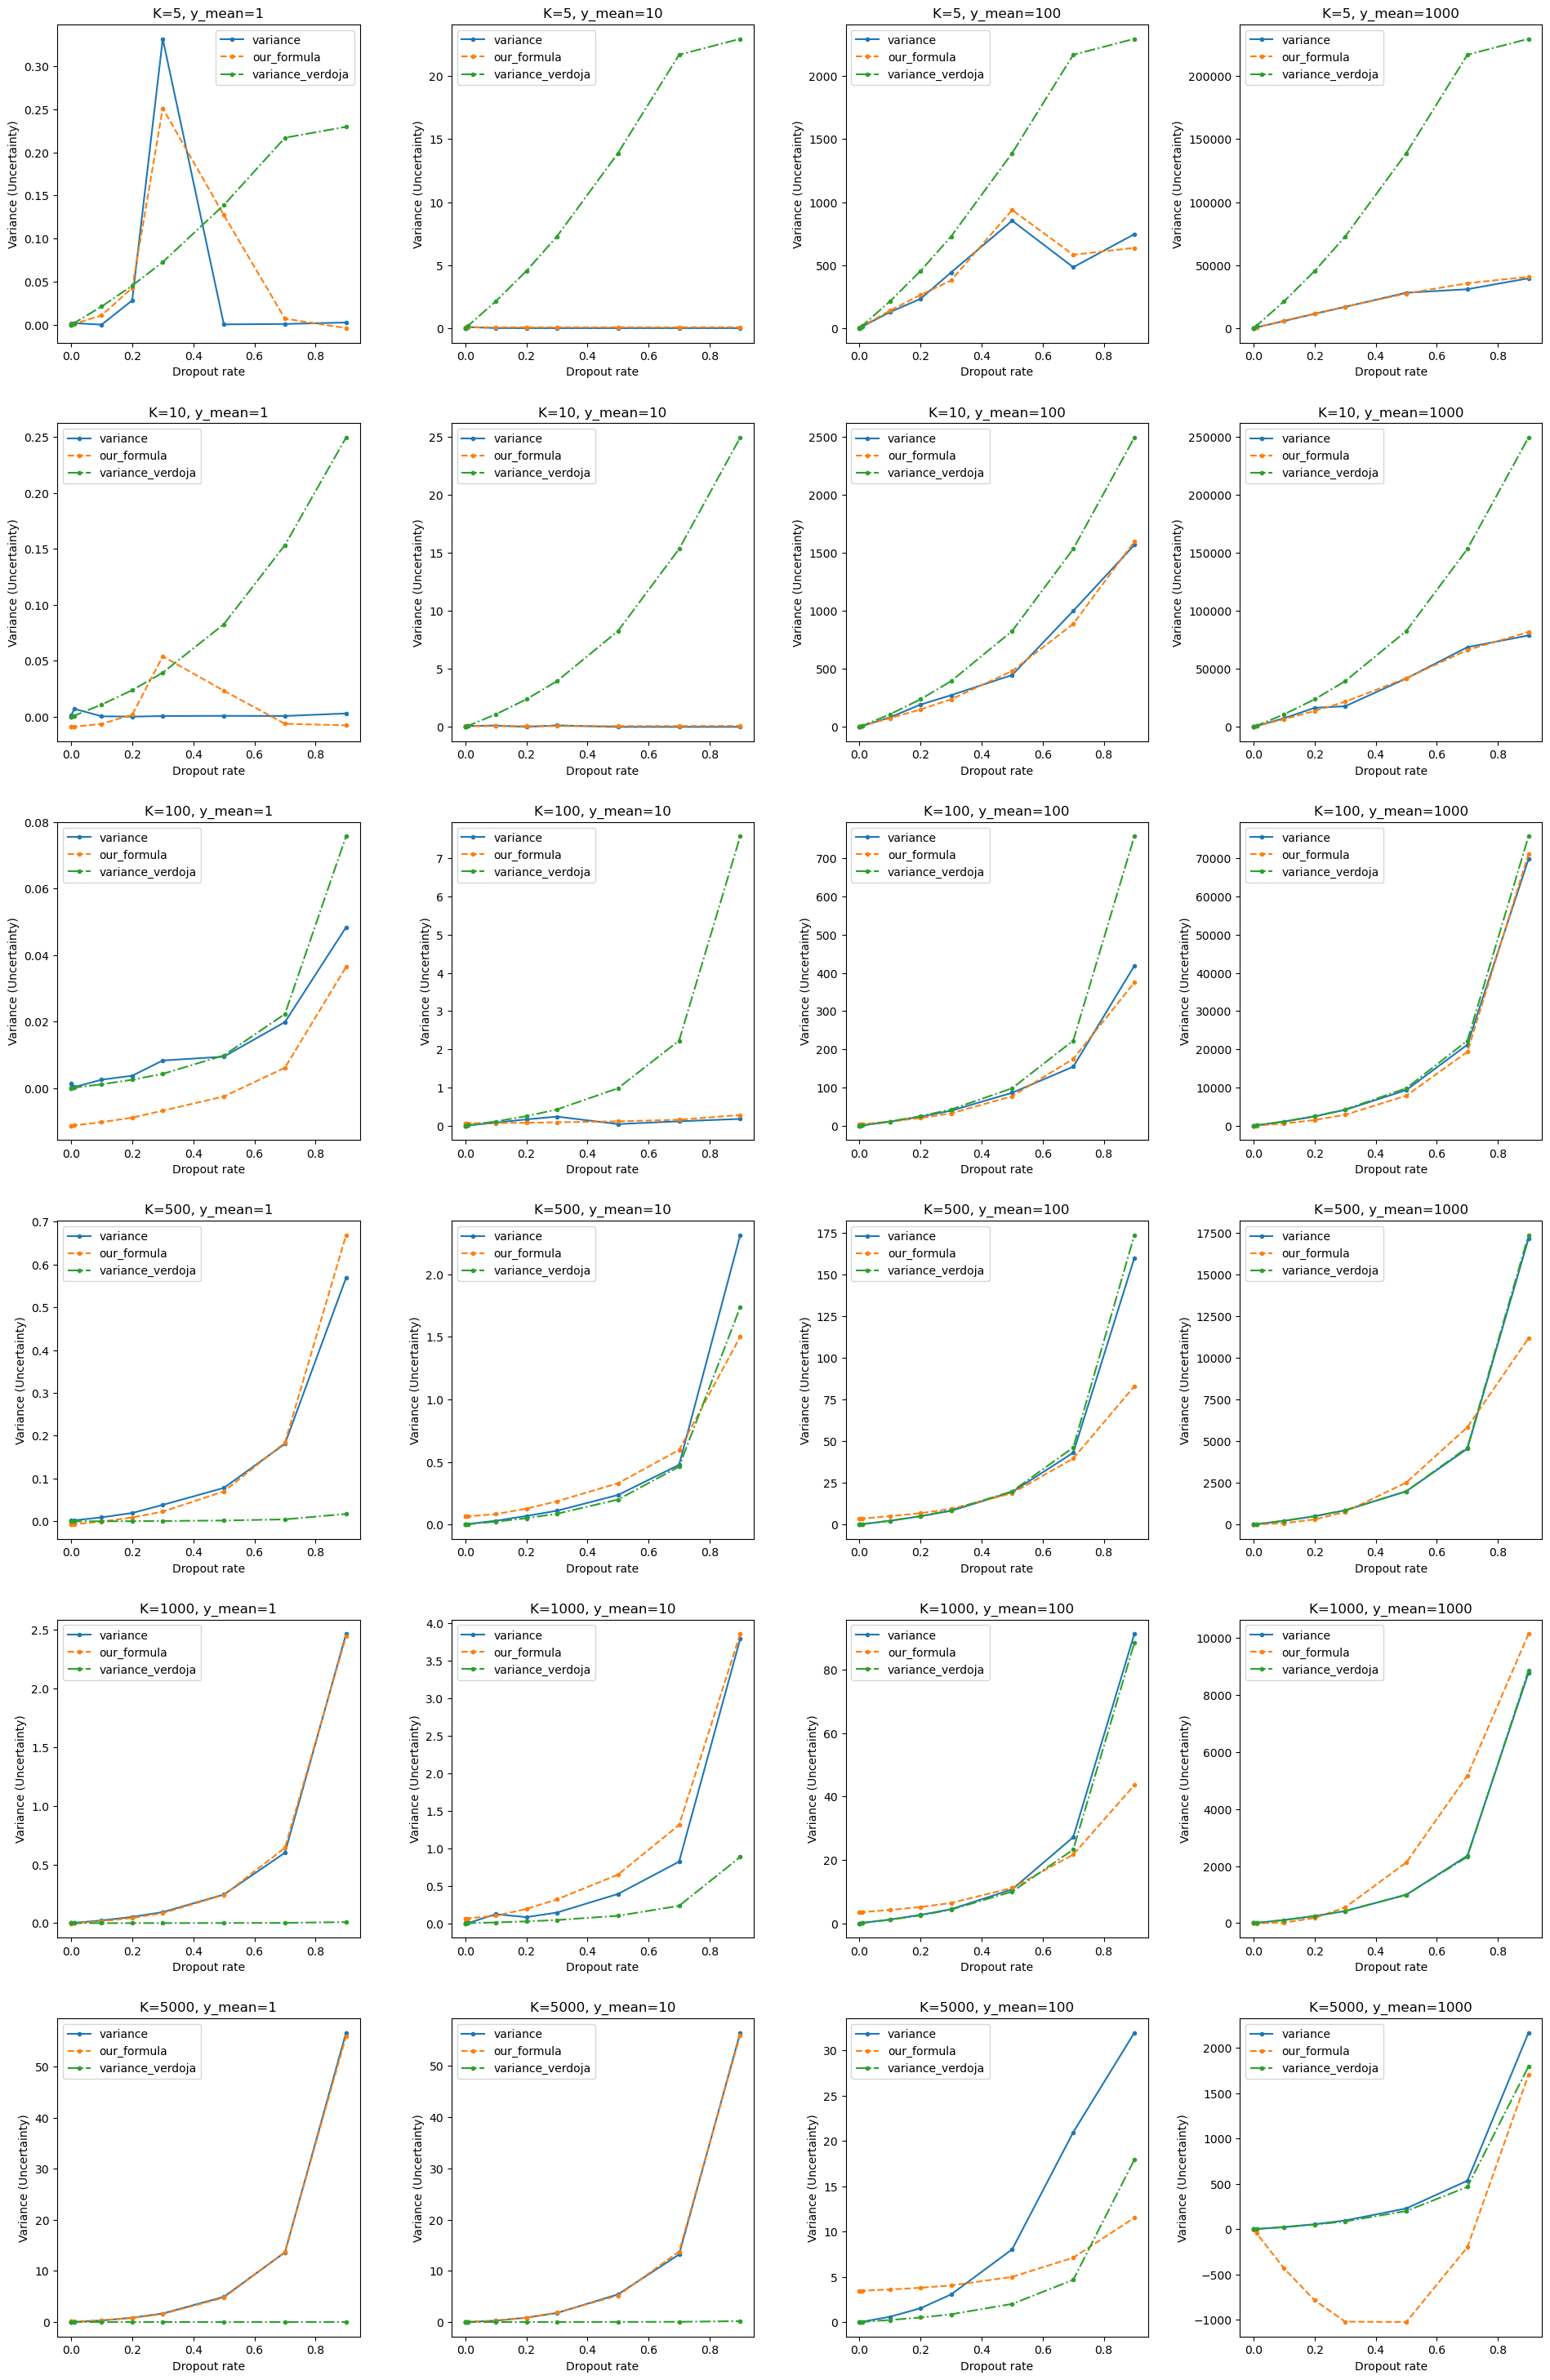

In [12]:
plot_examples(regression_data_0_layers, 
              ['variance', 'our_formula', 'variance_verdoja'], "0 Layer NN (personalized y_mean)")

/var/folders/rc/t3h_b88s3vbg5dcd4pnlgskr0000gp/T/ipykernel_73665/3329740331.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_data["K"] = subset_data["K"].astype(str)


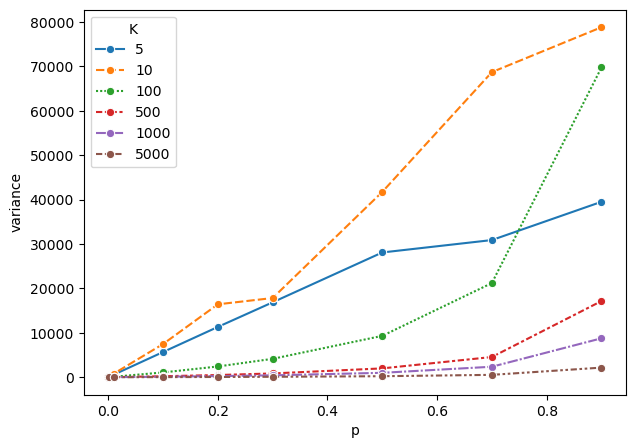

In [13]:
from scipy import linalg
import seaborn as sns
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

subset_data = regression_data_0_layers[regression_data_0_layers['y_mean'] == 1000]
subset_data["K"] = subset_data["K"].astype(str)
sns.lineplot(data=subset_data, x="p", y="variance", hue='K', ax=ax, style='K', marker='o')
# log y axis
# ax.set_yscale('log')
plt.show()

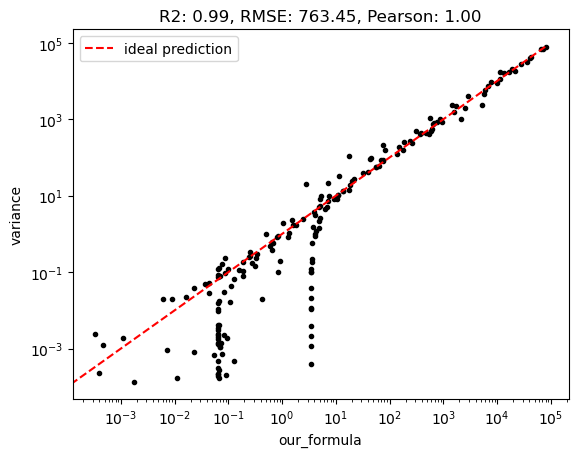

In [14]:
scatter_uncertainty(regression_data_0_layers, 'our_formula', 'variance', "0 Layer NN (personalized y_mean)")

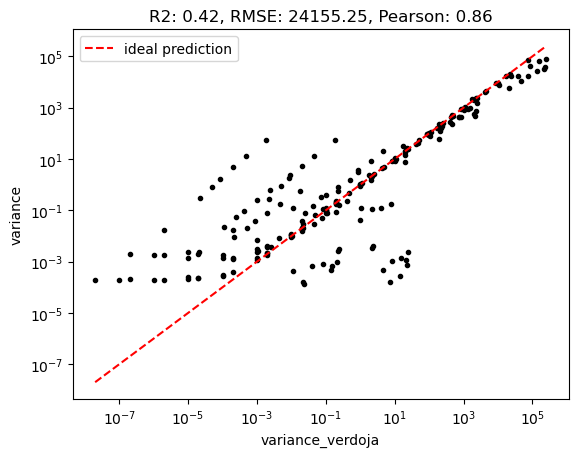

In [15]:
scatter_uncertainty(regression_data_0_layers, 'variance_verdoja', 'variance', "0 Layer NN (personalized y_mean)")